In [127]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

In [2]:
annual_value_adjusted = pd.read_csv("data/outputs/annual_ca_port",
                                    index_col =0, parse_dates = [1])
quarterly_value_adjusted = pd.read_csv('data/outputs/quarter_ca_port',
                                    index_col =0, parse_dates = [1])
band_value_adjusted = pd.read_csv("data/outputs/quarter_band_ca_port",
                                    index_col =0, parse_dates = [1])
asset_data = pd.read_csv("data/processed/daily_returns.csv",
                         parse_dates = [0])


In [3]:
annual_weights = pd.read_csv("data/outputs/annually_rebalanced_weights", 
                             index_col = 0, parse_dates = [1])
quarterly_weights = pd.read_csv("data/outputs/quarterly_rebalanced_weights", 
                                index_col = 0, parse_dates = [1])
band_weights = pd.read_csv("data/outputs/quarterly_rebalanced_byband_weights", 
                           index_col = 0, parse_dates = [1])

In [4]:
spy = asset_data[['Date','SPY']]
spy_data = spy[spy['Date'].isin(annual_value_adjusted['Date'])]

In [ ]:
def portfolio_holding_beta(weights_df, values_df, benchmark):
    
    beta_list = []

    summary_list = []

    starting_weights = weights_df[weights_df['weight_type'] == 'starting']

    start_dates = weights_df.loc[weights_df['weight_type'] == 'starting', 'Date']

    end_dates = weights_df.loc[weights_df['weight_type'] == 'ending', 'Date']

    for row in range(len(start_dates)):

        beta_series = pd.Series(index = values_df.columns, dtype = float).drop('Date')
        
        start = start_dates.iloc[row]
        
        end = end_dates.iloc[row]

        period_data = values_df[values_df['Date'].between(start, end)].drop(columns = 'Date')

        benchmark_var = values_df.loc[values_df['Date'].between(start, end), benchmark].var()

        for col in period_data.columns:
            cov = period_data[col].cov(period_data[benchmark])
            beta = cov / benchmark_var
            beta_series[col] = beta

        weights = starting_weights[starting_weights['Date'] == start].drop(columns = ['Date','weight_type'])
        weight_betas = weights.iloc[0] * beta_series
        period_beta = sum(weight_betas)

        beta_list.append({
            'start' : start,
            'end' : end,
            'beta': period_beta
        })

    summ = pd.concat([weights.iloc[0], beta_series, weight_betas], axis = 1)
    summ.columns = ['weight','beta','contribution']

    return pd.DataFrame(beta_list), summ


In [ ]:
annual_weighted_beta_df, annual_asset_betas = portfolio_holding_beta(annual_weights, asset_data, "SPY")
quarter_weighted_beta_df, quarterly_asset_betas = portfolio_holding_beta(quarterly_weights, asset_data, "SPY")
band_weighted_beta_df, banded_asset_betas = portfolio_holding_beta(band_weights, asset_data, "SPY")
    

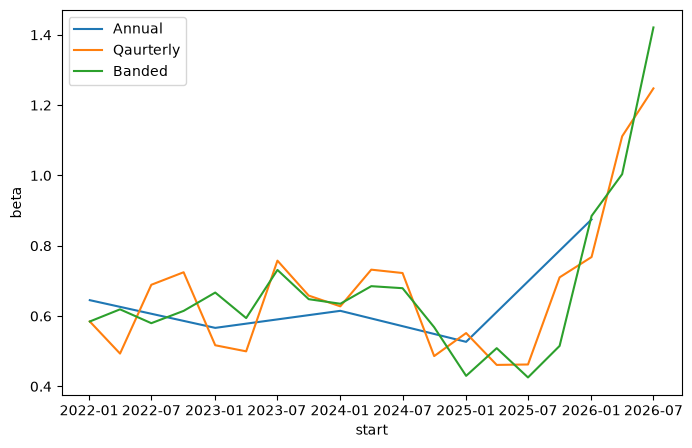

In [8]:
plt.figure(figsize = (8,5))
sns.lineplot(data = annual_weighted_beta_df, x = 'start', y = 'beta', label = 'Annual')
sns.lineplot(data = quarter_weighted_beta_df, x = 'start', y = 'beta', label = 'Qaurterly')
sns.lineplot(data = band_weighted_beta_df, x = 'start', y = 'beta', label = 'Banded')
plt.legend()

In [ ]:
quarterly_regression_data = quarterly_value_adjusted.merge(spy_data, on = 'Date')

quarterly_regression_data['portfolio_excess'] = quarterly_regression_data['portfolio_return'] - quarterly_regression_data['rf_rate']
quarterly_regression_data['market_excess'] = quarterly_regression_data['SPY'] - quarterly_regression_data['rf_rate']

model = smf.ols(formula= 'portfolio_excess~market_excess', data = quarterly_regression_data).fit()

exp_return_quarterly_ts = quarterly_regression_data['rf_rate'] + model.params.iloc[1] * (quarterly_regression_data['SPY']-quarterly_regression_data['rf_rate'])
exp_return_quarterly = quarterly_regression_data['rf_rate'].mean() + model.params.iloc[1] * (
    quarterly_regression_data['SPY'].mean()-quarterly_regression_data['rf_rate'].mean())

jensens_c_quarterly = quarterly_regression_data['portfolio_return'].mean() - exp_return_quarterly # Make all of this more organized

0       0.003516
1      -0.000202
2      -0.011655
3      -0.000569
4      -0.002398
          ...   
1128    0.005358
1129   -0.002824
1130   -0.001815
1131    0.005198
1132    0.002676
Length: 1133, dtype: float64

<Axes: xlabel='Date', ylabel='exp_return'>

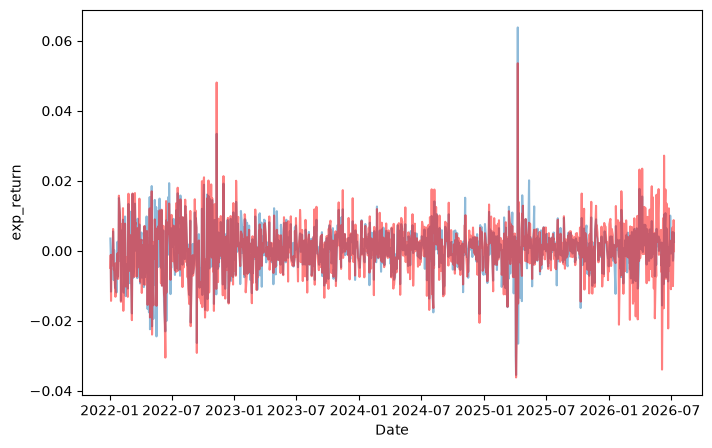

In [180]:
plt.figure(figsize = (8,5))
test= quarterly_regression_data.copy()
test['exp_return'] = exp_return_quarterly_ts
sns.lineplot(x = 'Date', y = 'exp_return', alpha = 0.5, data= test)
sns.lineplot(x = 'Date', y = 'portfolio_return', alpha = 0.5, color = 'red', data = quarterly_regression_data)

In [ ]:
def regression_analysis(portfolii_df, benchmark_df):

    regression_data = portfolii_df.merge(benchmark_df, on = 'Date')

    regression_data['portfolio_excess'] = regression_data['portfolio_return'] - regression_data['rf_rate']
    regression_data['market_excess'] = regression_data['SPY'] - regression_data['rf_rate']

    model = smf.ols(formula= 'portfolio_excess~market_excess', data = regression_data).fit()

    exp_return_ts = regression_data['rf_rate'] + model.params.iloc[1] * (regression_data['SPY']-regression_data['rf_rate'])
    exp_return = regression_data['rf_rate'].mean() + model.params.iloc[1] * (
        regression_data['SPY'].mean()-regression_data['rf_rate'].mean())

    jensens = regression_data['portfolio_return'].mean() - exp_return
    return model.params, exp_return, jensens # Make that more organized

In [168]:
regression_analysis(band_value_adjusted, spy_data)

(Intercept        0.000006
 market_excess    0.610285
 dtype: float64,
 np.float64(0.00038377940061215006),
 np.float64(5.8953759409834865e-06))

Treynor
Information Ratio
Tracking Error
Rolling Beta